# Traditional SPEN reconstruction, opened step by step

This notebook is deliberately not a final-image-only demo. It uses a synthetic SPEN acquisition first because synthetic data gives us something real scanner data cannot: a known true even/odd phase map.

The story is:

1. Start from a clean spin-density image.
2. Encode it through the SPEN forward model and inspect the low-resolution signal.
3. Look at the raw-like k-space and the readout-FFT image before correction.
4. Compare the true phase map against the estimated phase map.
5. Reconstruct the wrong way and the traditional way.
6. Inspect why `InvA` is a weighted adjoint, not a magic inverse.
7. Optionally run the same diagnostic idea on a real PV360 scan.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

torch.set_grad_enabled(False)
SEED = 20260518
torch.manual_seed(SEED)
np.random.seed(SEED)


def find_spenpy_repo(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in (start, *start.parents):
        if (path / 'pyproject.toml').exists() and (path / 'spenpy' / '__init__.py').exists():
            return path
        linked = path / 'spenpy'
        if (linked / 'pyproject.toml').exists() and (linked / 'spenpy' / '__init__.py').exists():
            return linked.resolve()
    fallback = Path('/home/data1/musong/workspace/python/spenpy')
    if fallback.exists():
        return fallback
    raise RuntimeError('Could not locate the spenpy repository root.')


SPENPY_REPO = find_spenpy_repo()
if str(SPENPY_REPO) not in sys.path:
    sys.path.insert(0, str(SPENPY_REPO))

from spenpy.fft.transform import fft_xspace_to_kspace
from spenpy.spen import spen

print('SPENPy repo:', SPENPY_REPO)


SPENPy repo: /home/data1/musong/workspace/python/spenpy


## Small plotting and metric helpers

Most intermediate arrays are complex-valued. The panels below show magnitudes unless the title says phase or error. Phase panels are wrapped to `[-pi, pi]`, which is the convention that makes phase jumps visible without unbounded color scales.

In [2]:
def to_numpy(x):
    if hasattr(x, 'detach'):
        return x.detach().cpu().resolve_conj().numpy()
    return np.asarray(x)


def first_2d(x):
    arr = np.asarray(to_numpy(x))
    arr = np.squeeze(arr)
    while arr.ndim > 2:
        arr = arr[..., 0]
    return arr


def abs_image(x):
    return np.abs(first_2d(x)).astype(np.float64)


def scale01(x, percentile=99.5):
    arr = abs_image(x)
    positive = arr[arr > 0]
    if positive.size == 0:
        return arr
    scale = np.percentile(positive, percentile)
    scale = scale if scale > 0 else float(arr.max())
    return np.clip(arr / max(scale, 1e-12), 0, 1)


def wrap_phase(x):
    return np.angle(np.exp(1j * first_2d(x).astype(np.float64)))


def metric_magnitude(x):
    arr = abs_image(x)
    return arr / max(float(arr.max()), 1e-12)


def metric_row(name, recon, reference):
    rec = metric_magnitude(recon)
    ref = metric_magnitude(reference)
    mse = float(np.mean((rec - ref) ** 2))
    rmse = mse ** 0.5
    psnr = 20 * np.log10(1.0 / max(rmse, 1e-12))
    nrmse = rmse / max(float(ref.max() - ref.min()), 1e-12)
    return name, psnr, nrmse


def show_panels(panels, ncols=4, title=None, figsize=None):
    n = len(panels)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    if figsize is None:
        figsize = (4.1 * ncols, 3.8 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, panel in zip(axes, panels):
        if len(panel) == 2:
            panel_title, data = panel
            kind = 'mag'
        else:
            panel_title, data, kind = panel

        if kind == 'phase':
            image = wrap_phase(data)
            im = ax.imshow(image, cmap='twilight', vmin=-np.pi, vmax=np.pi)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_ticks([-np.pi, 0, np.pi])
            cbar.set_ticklabels(['-pi', '0', 'pi'])
        elif kind == 'error':
            image = first_2d(data).astype(np.float64)
            vmax = np.percentile(np.abs(image), 99.0)
            vmax = vmax if vmax > 0 else 1.0
            im = ax.imshow(image, cmap='coolwarm', vmin=-vmax, vmax=vmax)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        elif kind == 'logmag':
            arr = abs_image(data)
            image = np.log1p(arr / max(float(arr.max()), 1e-12))
            image = image / max(float(image.max()), 1e-12)
            im = ax.imshow(image, cmap='viridis', vmin=0, vmax=1)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            im = ax.imshow(scale01(data), cmap='gray', vmin=0, vmax=1)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax.set_title(panel_title, fontsize=10)
        ax.set_axis_off()

    for ax in axes[n:]:
        ax.set_axis_off()
    if title:
        fig.suptitle(title, fontsize=13)
    plt.show()
    return fig


## 1. Clean object: what we wish the scanner had measured

The packaged `rat.png` is already 96 by 96, matching the scanner-like simulation profile. This image acts as the spin density. Nothing below is learned; every reconstruction panel comes from the traditional physical operators.

image: /home/data1/musong/workspace/python/spenpy/spenpy/data/rat.png
spin_density: (96, 96) torch.float32


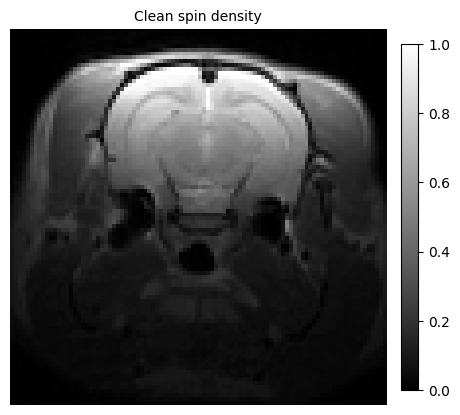

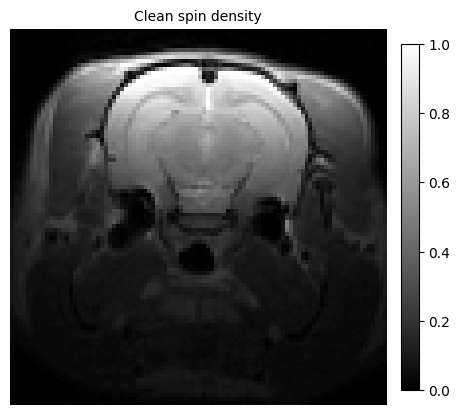

In [3]:
image_path = SPENPY_REPO / 'spenpy/data/rat.png'
if not image_path.exists():
    image_path = SPENPY_REPO / 'spenpy/data/brain.png'

img = Image.open(image_path).convert('L')
spin_density = torch.from_numpy(np.asarray(img, dtype=np.float32) / 255.0)
spin_density = spin_density / spin_density.max().clamp_min(1e-8)

print('image:', image_path)
print('spin_density:', tuple(spin_density.shape), spin_density.dtype)
show_panels([('Clean spin density', spin_density)], ncols=1, figsize=(4.5, 4.3))


## 2. Build the traditional SPEN operators

`AFinal` is the forward SPEN encoding matrix. `InvA` is the traditional weighted-adjoint reconstruction operator. In the MATLAB/PV360 path this is the role of `calcInvA` followed by `MultMatTensor(InvA, ROFFTedData)`.

The scanner-like YAML profile also injects realistic nuisance terms: B0 variation, shot phase, even/odd phase, trajectory shifts, noise, and occasional line events.

In [4]:
config_path = SPENPY_REPO / 'spenpy/configs/scanner_like.yaml'
sim = spen.from_yaml(config_path, seed=SEED)

InvA, AFinal = sim.get_InvA()
InvA = InvA.to(torch.complex64)
AFinal = AFinal.to(torch.complex64)

corrupted, phase_est, good_lr, sim_meta = sim.sim(
    spin_density.unsqueeze(0),
    return_phase_map=True,
    return_good_lr_image=True,
    return_metadata=True,
)
corrupted = corrupted.to(torch.complex64)
good_lr = good_lr.to(torch.complex64)
phase_est = phase_est.to(torch.float32)
phase_true = sim_meta['phase_map_true'].to(torch.float32)
shot_phase = sim_meta['shot_phase_map'].to(torch.float32)

reference = F.interpolate(
    spin_density[None, None].float(),
    size=corrupted.shape[1:],
    mode='bilinear',
    align_corners=False,
).squeeze(0).squeeze(0)

print('config        :', config_path)
print('InvA          :', tuple(InvA.shape), InvA.dtype)
print('AFinal        :', tuple(AFinal.shape), AFinal.dtype)
print('corrupted     :', tuple(corrupted.shape), corrupted.dtype)
print('phase_true    :', tuple(phase_true.shape), phase_true.dtype)
print('phase_est     :', tuple(phase_est.shape), phase_est.dtype)
print('good_lr       :', tuple(good_lr.shape), good_lr.dtype)
print('noise sample  :', sim_meta['noise'])
print('segment shift :', sim_meta['sampled']['segment_shift_cm'])


config        : /home/data1/musong/workspace/python/spenpy/spenpy/configs/scanner_like.yaml
InvA          : (96, 96) torch.complex64
AFinal        : (96, 96) torch.complex64
corrupted     : (1, 96, 96) torch.complex64
phase_true    : (1, 48, 96) torch.float32
phase_est     : (1, 48, 96) torch.float32
good_lr       : (1, 96, 96) torch.complex64
noise sample  : {'noise_std': 0.010592992067337036, 'spikes': 0, 'dropped_lines': 0}
segment shift : [0.005208151102066041]


## 3. What the traditional pipeline sees before reconstruction

The important distinction is where each operation lives:

- raw-like k-space is before the readout FFT;
- `corrupted` is after the readout FFT, where the even/odd phase correction is applied;
- `InvA` acts along the phase-encoding direction after phase correction.


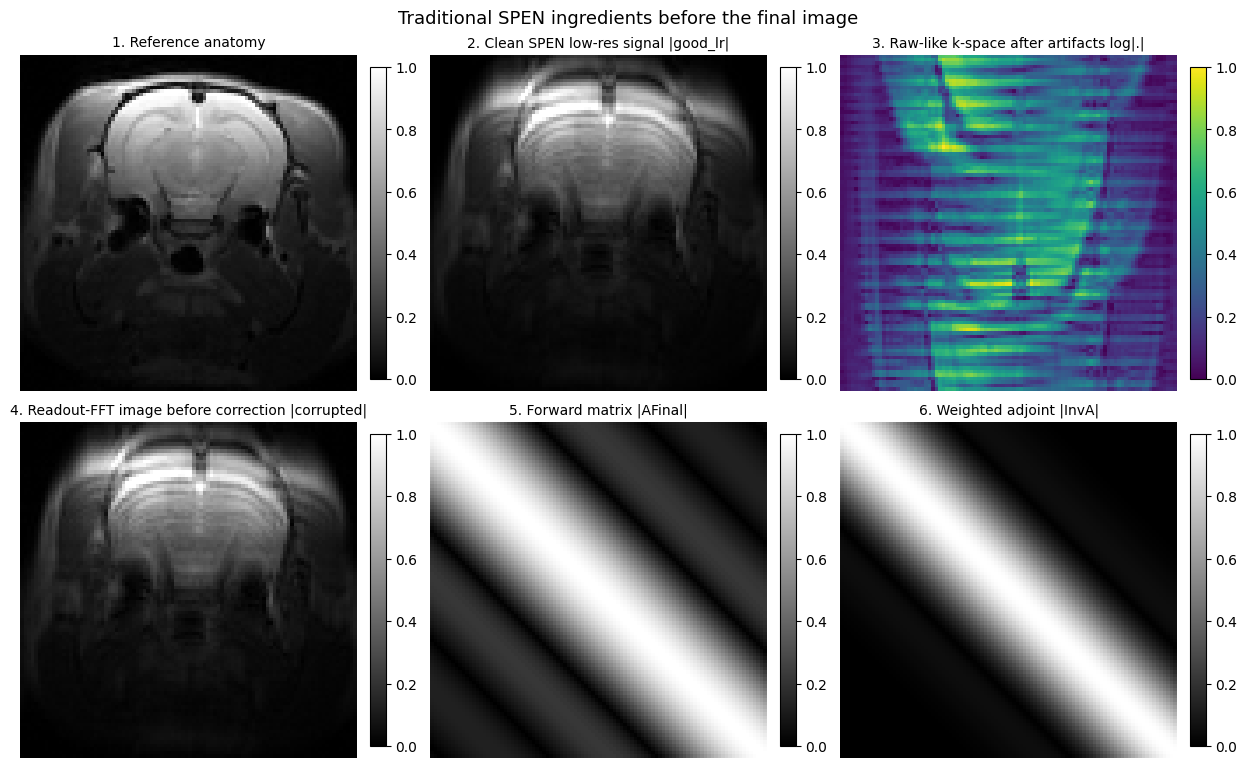

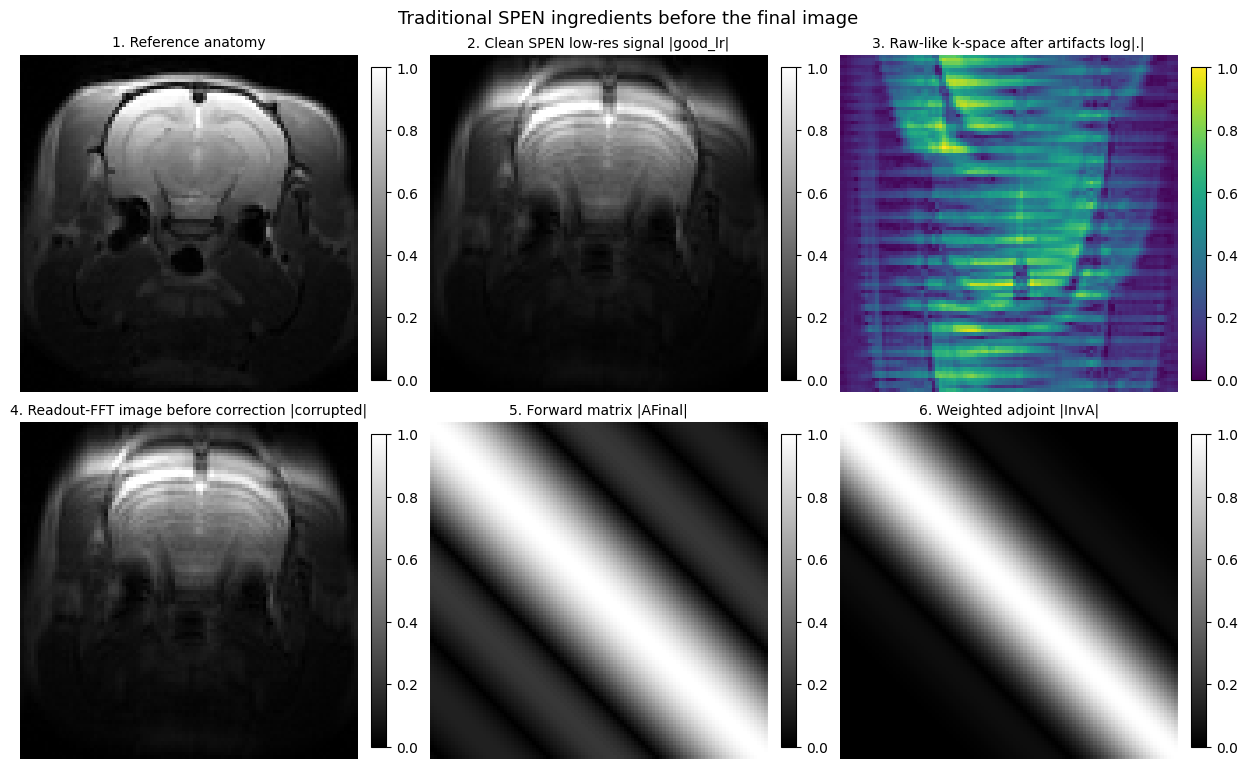

In [5]:
raw_like_kspace = fft_xspace_to_kspace(corrupted, dim=1)

show_panels(
    [
        ('1. Reference anatomy', reference, 'mag'),
        ('2. Clean SPEN low-res signal |good_lr|', good_lr[0], 'mag'),
        ('3. Raw-like k-space after artifacts log|.|', raw_like_kspace[0], 'logmag'),
        ('4. Readout-FFT image before correction |corrupted|', corrupted[0], 'mag'),
        ('5. Forward matrix |AFinal|', AFinal, 'mag'),
        ('6. Weighted adjoint |InvA|', InvA, 'mag'),
    ],
    ncols=3,
    title='Traditional SPEN ingredients before the final image',
)


## 4. The phase map is the hidden problem

Only the synthetic branch can show phase truth. In real scanner data, the best we can do is estimate phase from odd/even structure and inspect masks, fitted maps, and residuals. Here the truth panel gives us a clean teaching target.

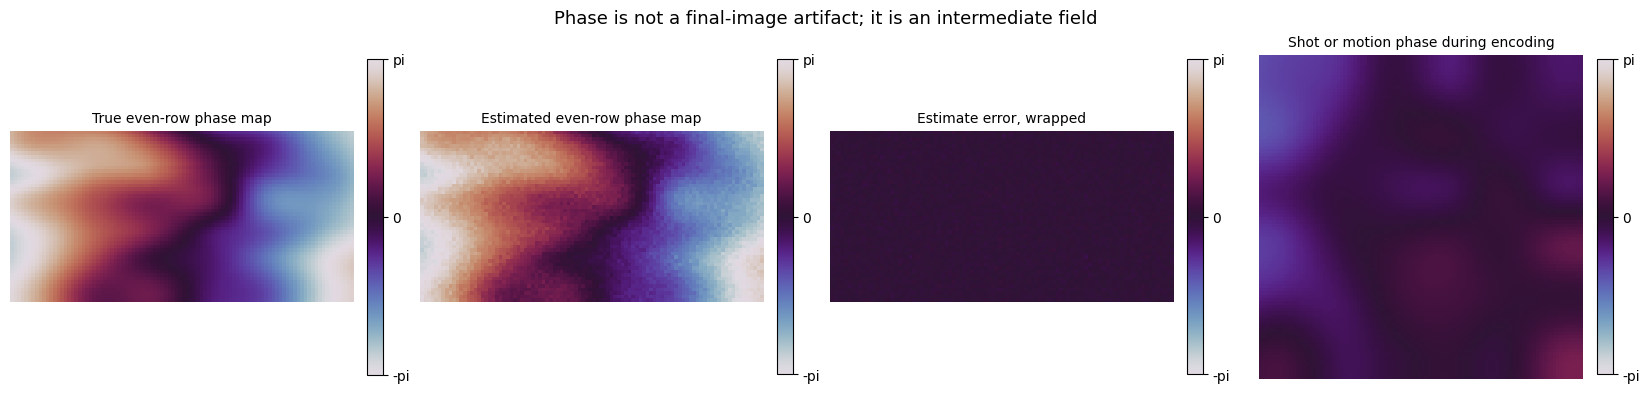

true phase range rad     : -3.5219194889068604 3.5333590507507324
estimated phase range rad: -3.609833240509033 3.585134267807007
wrapped estimate error std rad: 0.058997538719501044


In [6]:
phase_error = phase_est - phase_true
shot_to_show = shot_phase[0, 0].T if shot_phase.ndim == 4 else shot_phase[0]

show_panels(
    [
        ('True even-row phase map', phase_true[0], 'phase'),
        ('Estimated even-row phase map', phase_est[0], 'phase'),
        ('Estimate error, wrapped', phase_error[0], 'phase'),
        ('Shot or motion phase during encoding', shot_to_show, 'phase'),
    ],
    ncols=4,
    title='Phase is not a final-image artifact; it is an intermediate field',
)

wrapped_error = wrap_phase(phase_error[0])
print('true phase range rad     :', float(phase_true.min()), float(phase_true.max()))
print('estimated phase range rad:', float(phase_est.min()), float(phase_est.max()))
print('wrapped estimate error std rad:', float(wrapped_error.std()))


## 5. Reconstruct the wrong way and the traditional way

The phase correction has to happen before `InvA`. If we multiply by `InvA` first, the row-wise phase error has already been mixed across the image and cannot be cleanly undone as an even-row correction.

The `true phase` reconstruction is an oracle upper bound. The `estimated phase` reconstruction is the realistic synthetic path.

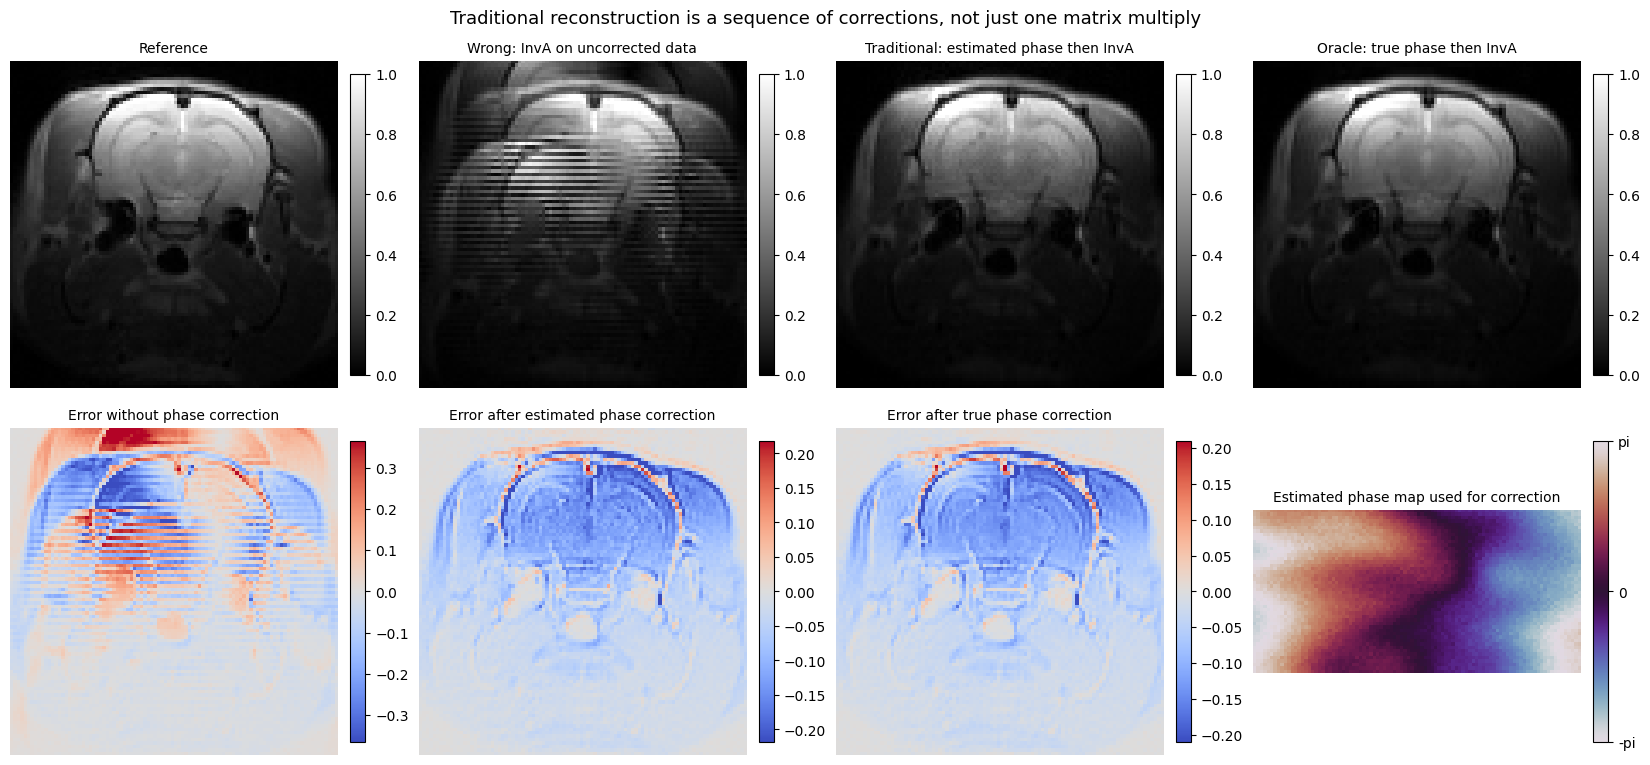

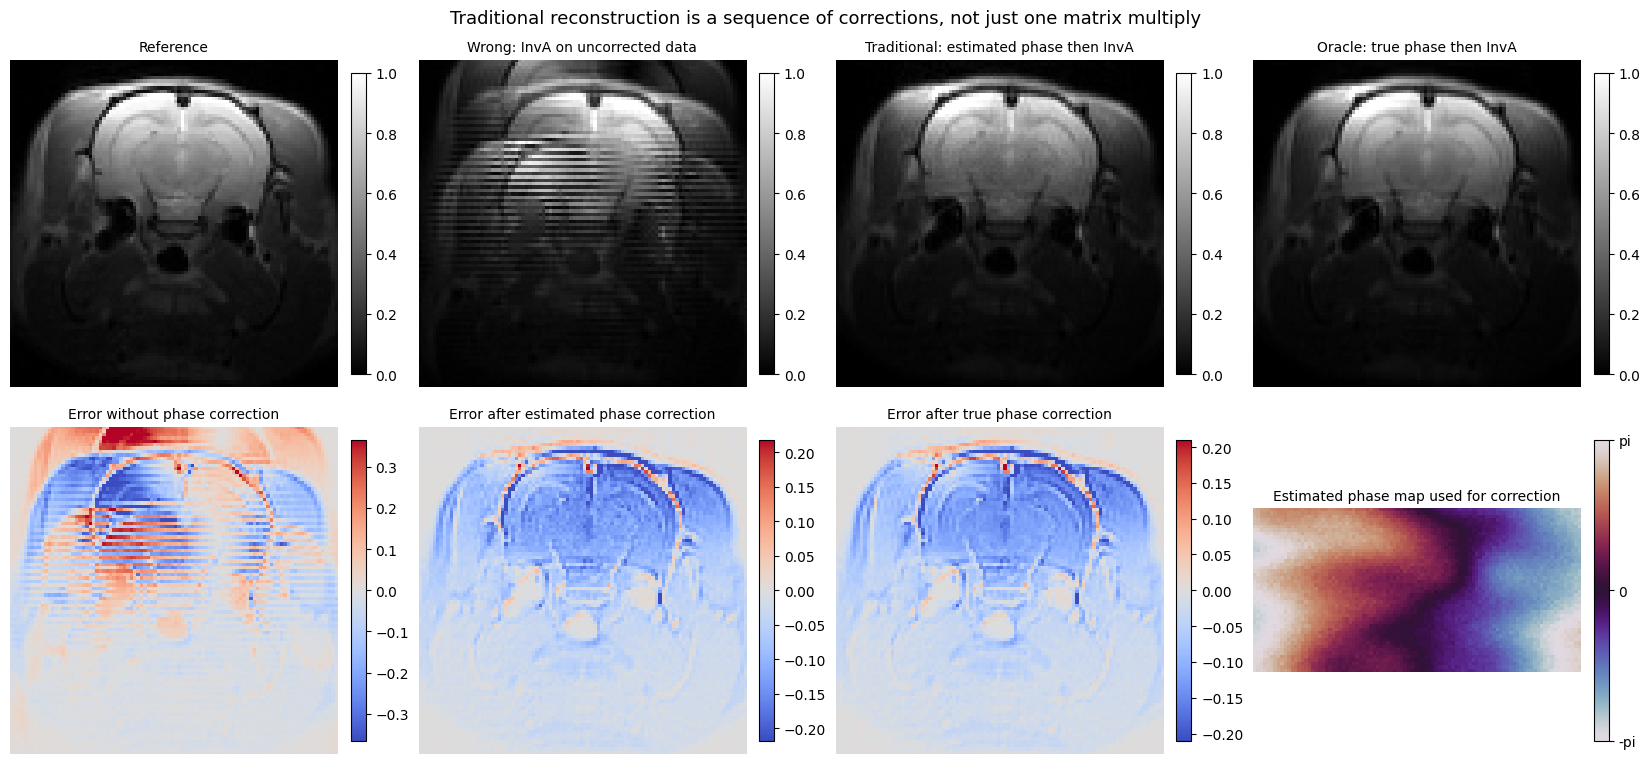

In [7]:
recon_no_phase = torch.matmul(InvA, corrupted)

corrected_with_true = corrupted.clone()
corrected_with_true[:, 1::2, :] *= torch.exp(-1j * phase_true)
recon_true_phase = torch.matmul(InvA, corrected_with_true)

corrected_with_est = corrupted.clone()
corrected_with_est[:, 1::2, :] *= torch.exp(-1j * phase_est)
recon_est_phase = torch.matmul(InvA, corrected_with_est)

ref01 = metric_magnitude(reference)
no_phase_error = metric_magnitude(recon_no_phase[0]) - ref01
est_phase_error = metric_magnitude(recon_est_phase[0]) - ref01
true_phase_error = metric_magnitude(recon_true_phase[0]) - ref01

show_panels(
    [
        ('Reference', reference, 'mag'),
        ('Wrong: InvA on uncorrected data', recon_no_phase[0], 'mag'),
        ('Traditional: estimated phase then InvA', recon_est_phase[0], 'mag'),
        ('Oracle: true phase then InvA', recon_true_phase[0], 'mag'),
        ('Error without phase correction', no_phase_error, 'error'),
        ('Error after estimated phase correction', est_phase_error, 'error'),
        ('Error after true phase correction', true_phase_error, 'error'),
        ('Estimated phase map used for correction', phase_est[0], 'phase'),
    ],
    ncols=4,
    title='Traditional reconstruction is a sequence of corrections, not just one matrix multiply',
)


## 6. Put numbers next to the images

These metrics are not meant as a benchmark. They are a sanity check for the visual story: correcting phase before the SPEN adjoint should move the reconstruction closer to the reference.

method                                PSNR     NRMSE
------------------------------------------------------
InvA on uncorrected data             19.18    0.1100
Estimated phase then InvA            22.80    0.0724
True phase then InvA                 23.02    0.0706


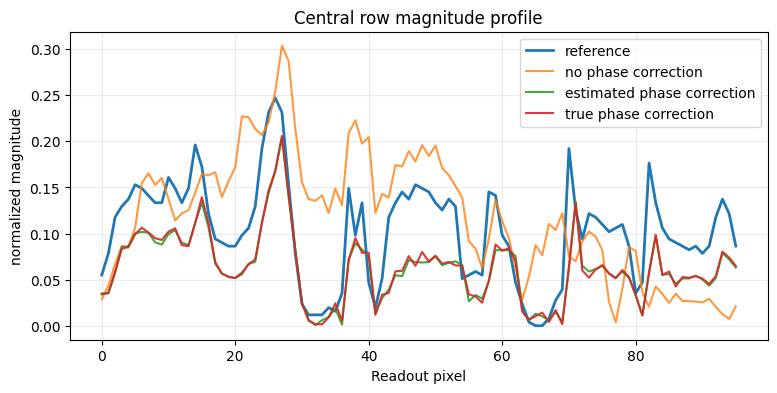

In [8]:
rows = [
    metric_row('InvA on uncorrected data', recon_no_phase[0], reference),
    metric_row('Estimated phase then InvA', recon_est_phase[0], reference),
    metric_row('True phase then InvA', recon_true_phase[0], reference),
]

print('{:<32s}  {:>8s}  {:>8s}'.format('method', 'PSNR', 'NRMSE'))
print('-' * 54)
for name, psnr, nrmse in rows:
    print(f'{name:32s}  {psnr:8.2f}  {nrmse:8.4f}')

mid = reference.shape[0] // 2
plt.figure(figsize=(9, 4))
plt.plot(metric_magnitude(reference)[mid], label='reference', linewidth=2)
plt.plot(metric_magnitude(recon_no_phase[0])[mid], label='no phase correction', alpha=0.8)
plt.plot(metric_magnitude(recon_est_phase[0])[mid], label='estimated phase correction', alpha=0.9)
plt.plot(metric_magnitude(recon_true_phase[0])[mid], label='true phase correction', alpha=0.9)
plt.title('Central row magnitude profile')
plt.xlabel('Readout pixel')
plt.ylabel('normalized magnitude')
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 7. Why the oracle is still not perfect

`InvA` is a weighted adjoint built from the SPEN encoding matrix. It is intentionally stable, but it is not an exact inverse. The matrix product `InvA @ AFinal` is a point-spread view of the traditional operator: diagonal energy is good, off-diagonal energy is blur or leakage.

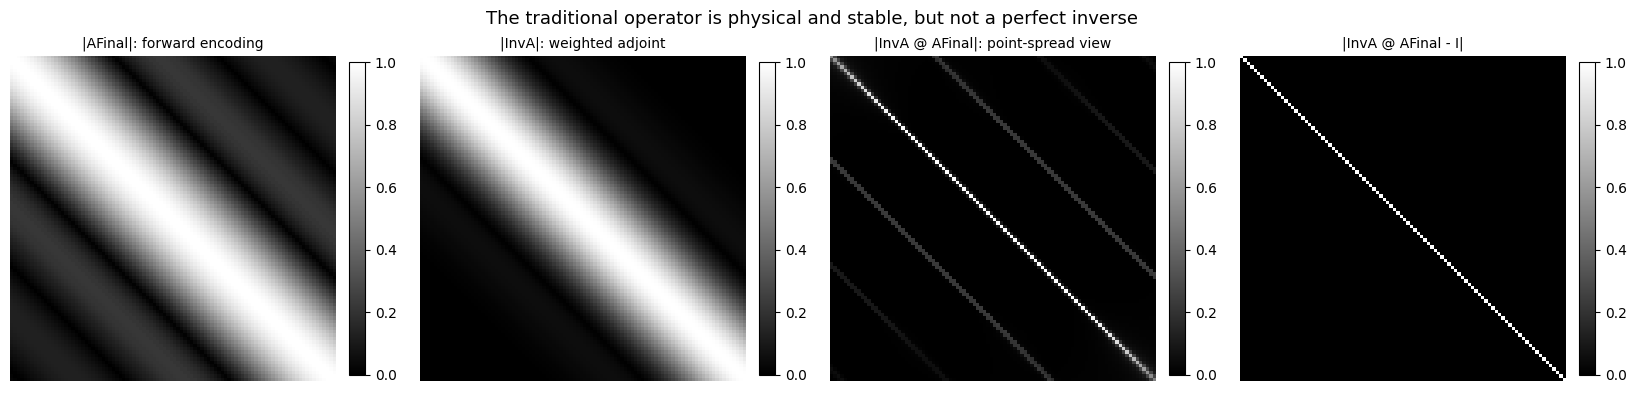

mean diagonal response    : 0.00656
mean off-diagonal response: 0.0001


In [9]:
system_response = torch.matmul(InvA, AFinal)
identity = torch.eye(system_response.shape[0], dtype=system_response.dtype)
off_diagonal = torch.abs(system_response - identity)

show_panels(
    [
        ('|AFinal|: forward encoding', AFinal, 'mag'),
        ('|InvA|: weighted adjoint', InvA, 'mag'),
        ('|InvA @ AFinal|: point-spread view', system_response, 'mag'),
        ('|InvA @ AFinal - I|', off_diagonal, 'mag'),
    ],
    ncols=4,
    title='The traditional operator is physical and stable, but not a perfect inverse',
)

resp = torch.abs(system_response)
diag_mean = torch.diag(resp).mean().item()
off_mean = (resp.sum() - torch.diag(resp).sum()).item() / (resp.numel() - resp.shape[0])
print('mean diagonal response    :', round(diag_mean, 5))
print('mean off-diagonal response:', round(off_mean, 5))


## 8. A single teaching storyboard

This condensed figure is useful for slides or a lab discussion. Set `SAVE_SUMMARY = True` if you want a PNG copy under `spenpy/demo/outputs/`.

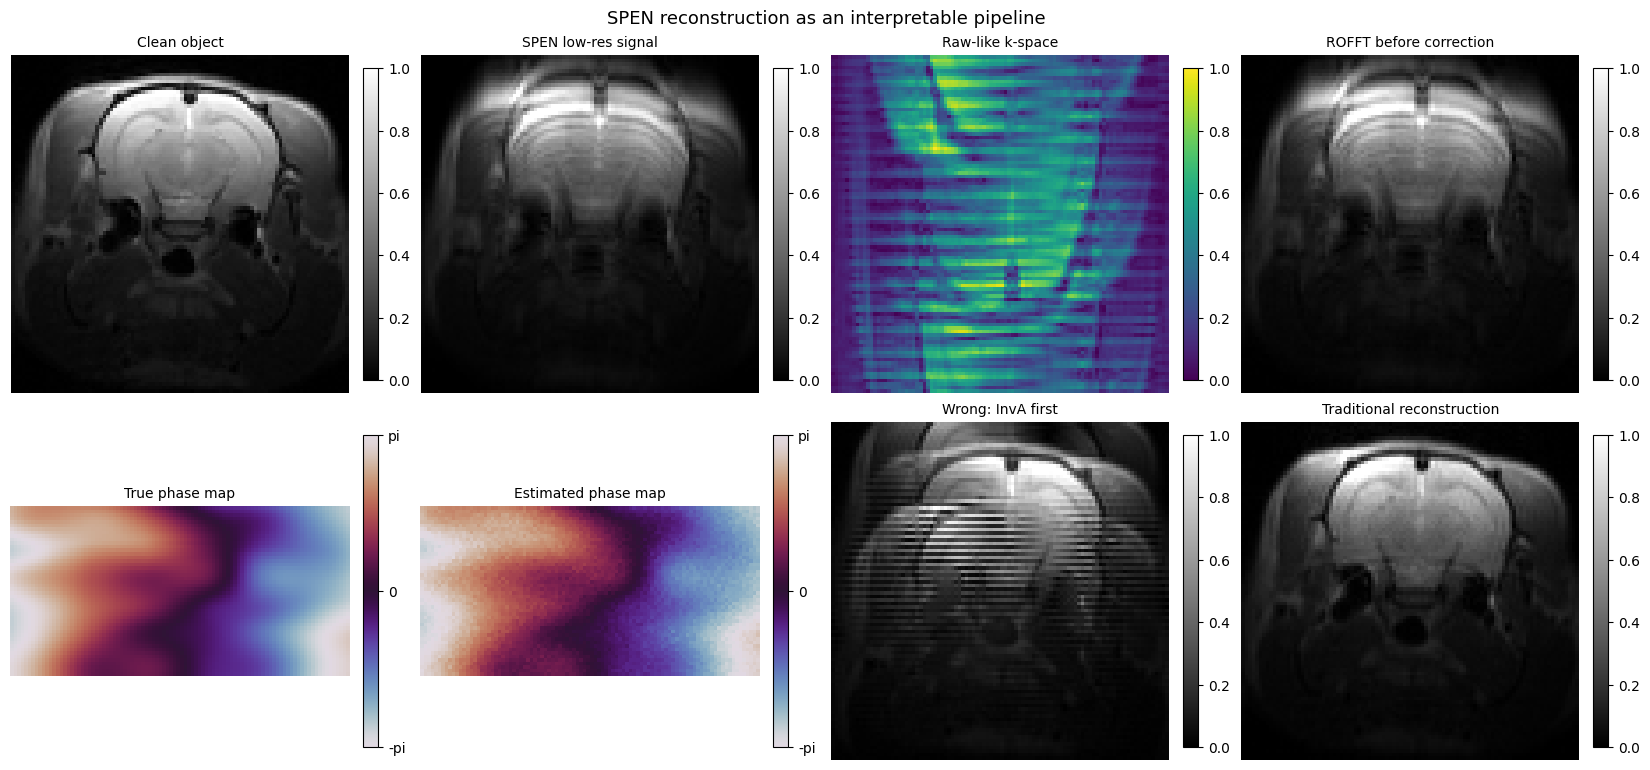

In [10]:
SAVE_SUMMARY = False
summary_dir = SPENPY_REPO / 'demo/outputs'
summary_path = summary_dir / 'traditional_reconstruction_storyboard.png'

fig = show_panels(
    [
        ('Clean object', reference, 'mag'),
        ('SPEN low-res signal', good_lr[0], 'mag'),
        ('Raw-like k-space', raw_like_kspace[0], 'logmag'),
        ('ROFFT before correction', corrupted[0], 'mag'),
        ('True phase map', phase_true[0], 'phase'),
        ('Estimated phase map', phase_est[0], 'phase'),
        ('Wrong: InvA first', recon_no_phase[0], 'mag'),
        ('Traditional reconstruction', recon_est_phase[0], 'mag'),
    ],
    ncols=4,
    title='SPEN reconstruction as an interpretable pipeline',
)

if SAVE_SUMMARY:
    summary_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(summary_path, dpi=180)
    print('saved:', summary_path)


## 9. Optional: apply the same inspection idea to real PV360 data

Real scanner data has no true phase map, so this section visualizes fitted phase diagnostics instead of truth. It is off by default because regridding a real SPEN scan is slower than the synthetic example.

Change `RUN_REAL_DATA` to `True` when you want to inspect one real scan.

In [11]:
RUN_REAL_DATA = False
REAL_DATA_DIR = Path('/home/data1/musong/workspace/python/spen_recons/spen_matlab/data/20240321_204022_lxj_spen_mouse_240321_1_1_1')
SPEN_INDEX = 1
IMAGE_INDEX = 0

if RUN_REAL_DATA:
    from spenpy.cli.pv360 import read_datalist
    from spenpy.recon import orient_pv360_spen_image, reconstruct_odd_segments

    rare_id, epi_id, spen_ids = read_datalist(str(REAL_DATA_DIR))
    del rare_id, epi_id
    scan_id = spen_ids[SPEN_INDEX - 1]
    scan_dir = REAL_DATA_DIR / str(scan_id)
    print('real scan:', scan_dir)

    real_recon = reconstruct_odd_segments(
        str(scan_dir),
        return_phase_diagnostics=True,
        smooth_motion_phase_between_shots=True,
    )
    diagnostics = real_recon.phase_diagnostics[-1] if real_recon.phase_diagnostics else None
    refined_fit = None
    motion_fit = None
    if diagnostics and diagnostics.refined_even_odd:
        refined_fit = diagnostics.refined_even_odd[IMAGE_INDEX]
    if diagnostics and diagnostics.motion_between_shots:
        motion_fit = diagnostics.motion_between_shots[IMAGE_INDEX]

    imag_origin = orient_pv360_spen_image(to_numpy(real_recon.imag_origin))
    imag_low = orient_pv360_spen_image(to_numpy(real_recon.imag_low))
    image_spen = orient_pv360_spen_image(to_numpy(real_recon.images))

    real_panels = [
        ('Imag_origin: FFT-only view', imag_origin, 'mag'),
        ('Imag_low: after phase correction', imag_low, 'mag'),
        ('Image_SPEN: SR-corrected final', image_spen, 'mag'),
    ]
    if refined_fit is not None:
        real_panels.extend([
            ('Real-data odd/even phase difference', refined_fit.phase_difference, 'phase'),
            ('Real-data refined SmoothPhase', refined_fit.smooth_phase, 'phase'),
            ('Real-data phase mask', refined_fit.mask, 'mag'),
        ])
    if motion_fit is not None:
        real_panels.append(('Real-data motion SmoothPhase', motion_fit.smooth_phase, 'phase'))

    show_panels(real_panels, ncols=3, title='Real PV360 SPEN diagnostics')
else:
    print('RUN_REAL_DATA is False. Set it to True to reconstruct and inspect one PV360 scan.')


RUN_REAL_DATA is False. Set it to True to reconstruct and inspect one PV360 scan.


## Takeaways

- Traditional SPEN reconstruction is a staged physical pipeline: k-space handling, readout FFT, phase correction, weighted-adjoint SPEN reconstruction, and magnitude/orientation.
- The phase map is an intermediate object worth visualizing. With simulation we can compare the estimate to truth; with scanner data we inspect fitted phase maps and masks.
- `InvA` is not a black box. Visualizing `AFinal`, `InvA`, and `InvA @ AFinal` explains both the power and the limits of the traditional reconstruction.
- These intermediate panels make deep-learning refiners easier to reason about: a good model should respect this structure instead of hiding all errors in a final image.